In [1]:
import pandas as pd
import numpy as np
import missingno as msno
from sklearn.impute import KNNImputer
import seaborn as sns
import matplotlib.pyplot as plt

# Import TidyTuesday health dataset
health = pd.read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2026/2026-09-29/health.csv')

health.head(5)

,ID_UC_G0,GC_UCN_MAI_2025,GC_CNT_GAD_2025,GC_UCA_KM2_2025,GC_POP_TOT_2025,GC_DEV_WIG_2025,GC_DEV_USR_2025,HL_FCL_HOS_2024,HL_FCL_PHA_2024,HL_FDE_HOS_2024,HL_FDE_PHA_2024,HL_FPC_HOS_2025,HL_FPC_PHA_2025,HL_POP_HOS_2025,HL_POP_PHA_2025,HL_SHP_HOS_2025,HL_SHP_PHA_2025
0,1,Apia,Samoa,35,60041.65661,Lower Middle,Oceania,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,Nuku'alofa,Tonga,20,51990.76620,Upper Middle,Oceania,2.0,NaN,0.100000,NaN,0.000039,NaN,10751.55942,NaN,20.679748,NaN
2,3,Ewa Beach,United States,15,53720.65818,High income,Northern America,NaN,2.0,NaN,0.133333,NaN,0.000037,11160.55769,16640.80882,20.775169,30.976554
3,4,Papeete,French Polynesia,50,109747.12570,High income,Oceania,6.0,10.0,0.120000,0.200000,0.000055,0.000091,22890.40022,31177.61323,20.857403,28.408592
4,5,Rosarito,México,29,76707.05999,Upper Middle,Latin America and the Caribbean,6.0,8.0,0.206897,0.275862,0.000078,0.000104,23776.14037,22793.83739,30.996026,29.715436


<Axes: >

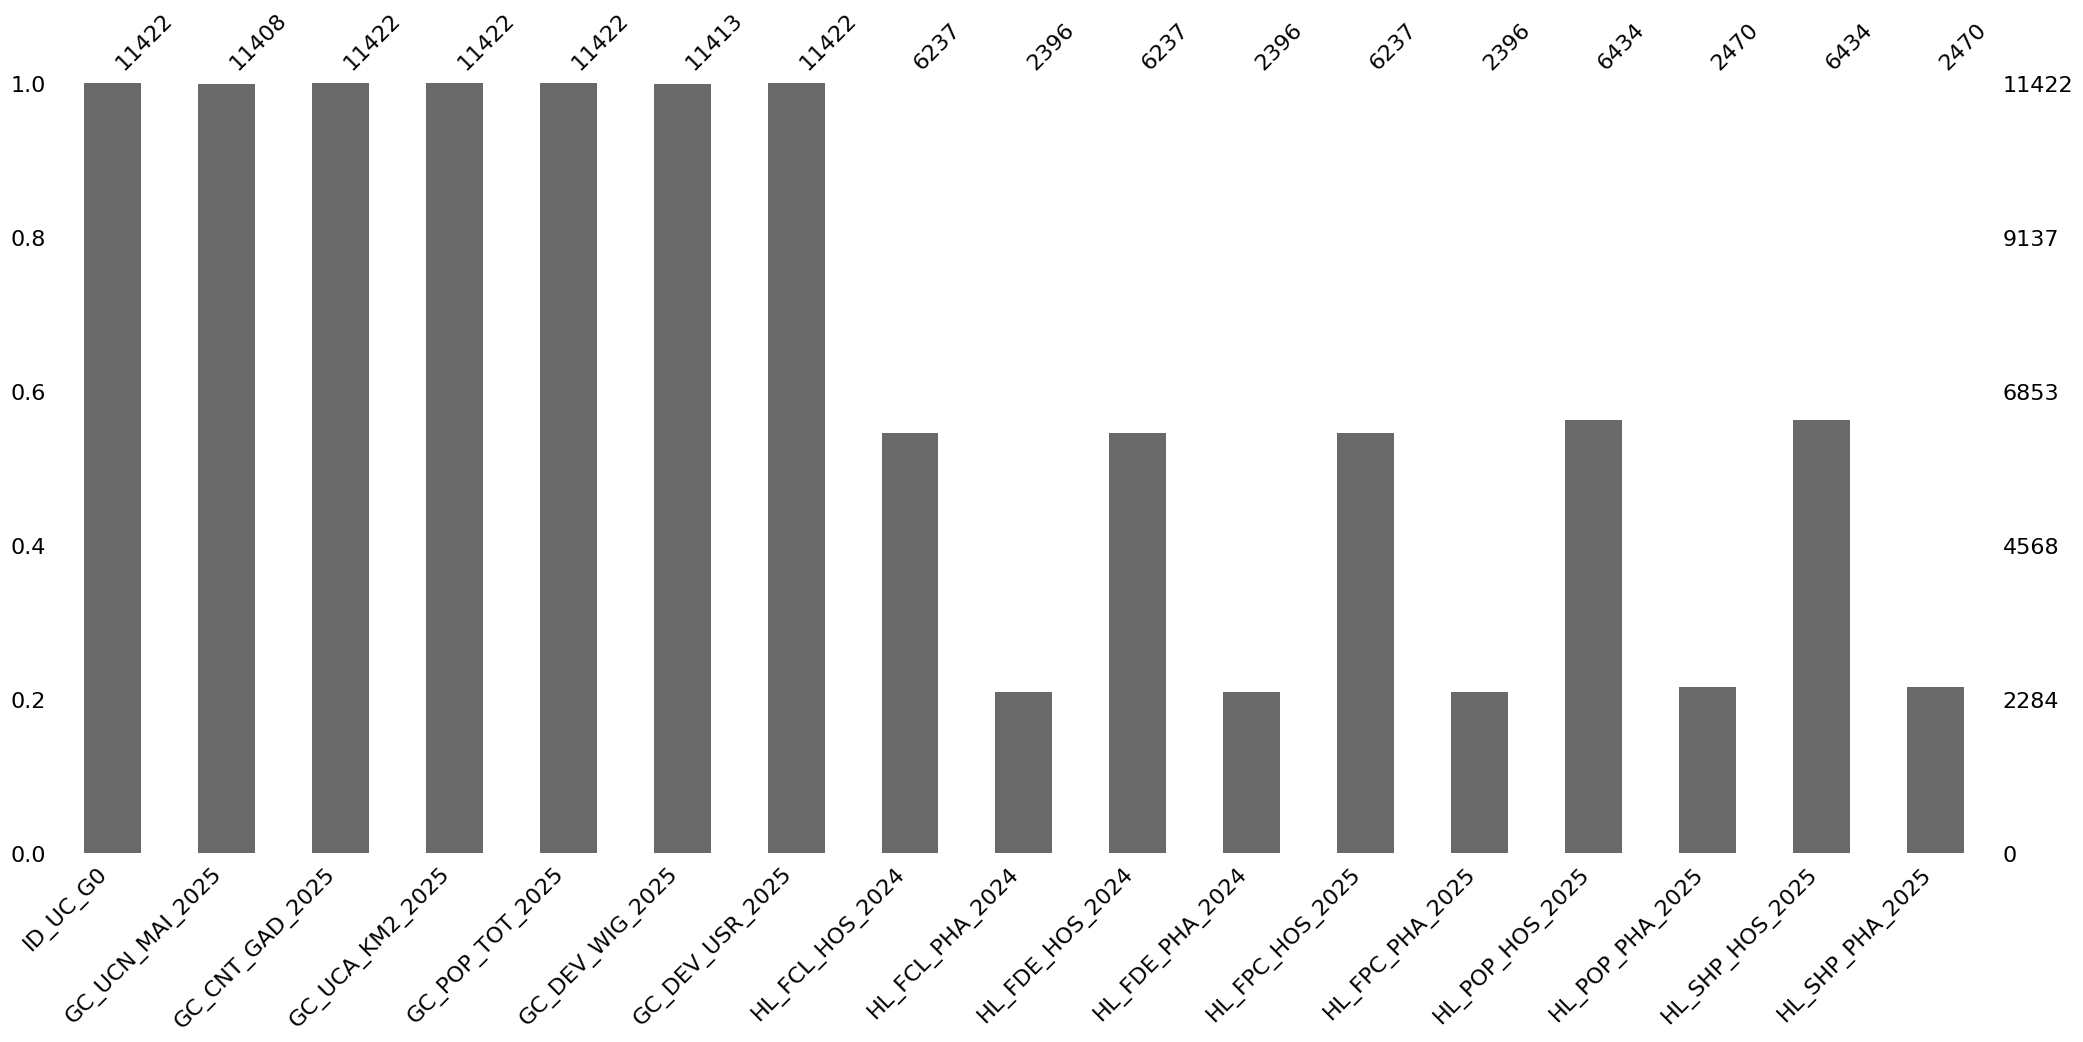

In [2]:
# Check null values

msno.bar(health)

In [3]:
# Count the number of missing values in each column
missing_values = health.isnull().sum().sort_values(ascending=False)
missing_percentage = (missing_values / len(health)) * 100
print(pd.DataFrame({'Missing Values': missing_values, 'Percentage': missing_percentage}))

                 Missing Values  Percentage
HL_FCL_PHA_2024            9026   79.022938
HL_FPC_PHA_2025            9026   79.022938
HL_FDE_PHA_2024            9026   79.022938
HL_POP_PHA_2025            8952   78.375066
HL_SHP_PHA_2025            8952   78.375066
HL_FDE_HOS_2024            5185   45.394852
HL_FCL_HOS_2024            5185   45.394852
HL_FPC_HOS_2025            5185   45.394852
HL_POP_HOS_2025            4988   43.670110
HL_SHP_HOS_2025            4988   43.670110
GC_UCN_MAI_2025              14    0.122570
GC_DEV_WIG_2025               9    0.078795
ID_UC_G0                      0    0.000000
GC_DEV_USR_2025               0    0.000000
GC_CNT_GAD_2025               0    0.000000
GC_UCA_KM2_2025               0    0.000000
GC_POP_TOT_2025               0    0.000000


In [4]:
# Check the number of duplicates
health.duplicated().sum()

np.int64(0)

In [5]:
# Check dataset types
health.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11422 entries, 0 to 11421
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID_UC_G0         11422 non-null  int64  
 1   GC_UCN_MAI_2025  11408 non-null  object 
 2   GC_CNT_GAD_2025  11422 non-null  object 
 3   GC_UCA_KM2_2025  11422 non-null  int64  
 4   GC_POP_TOT_2025  11422 non-null  float64
 5   GC_DEV_WIG_2025  11413 non-null  object 
 6   GC_DEV_USR_2025  11422 non-null  object 
 7   HL_FCL_HOS_2024  6237 non-null   float64
 8   HL_FCL_PHA_2024  2396 non-null   float64
 9   HL_FDE_HOS_2024  6237 non-null   float64
 10  HL_FDE_PHA_2024  2396 non-null   float64
 11  HL_FPC_HOS_2025  6237 non-null   float64
 12  HL_FPC_PHA_2025  2396 non-null   float64
 13  HL_POP_HOS_2025  6434 non-null   float64
 14  HL_POP_PHA_2025  2470 non-null   float64
 15  HL_SHP_HOS_2025  6434 non-null   float64
 16  HL_SHP_PHA_2025  2470 non-null   float64
dtypes: float64(1

In [6]:
# Check numerical statistics
health.describe().T

,count,mean,std,min,25%,50%,75%,max
ID_UC_G0,11422.0,5863.438189,3.382803e+03,1.000000e+00,2925.250000,5874.500000,8799.750000,1.168600e+04
GC_UCA_KM2_2025,11422.0,56.818858,1.850539e+02,1.000000e+00,13.000000,23.000000,44.000000,6.611000e+03
GC_POP_TOT_2025,11422.0,322653.884159,1.315393e+06,5.000775e+04,69478.661182,104136.117300,204771.261500,4.298770e+07
HL_FCL_HOS_2024,6237.0,15.467853,4.288292e+01,2.000000e+00,2.000000,6.000000,12.000000,1.016000e+03
HL_FCL_PHA_2024,2396.0,18.062604,5.629036e+01,2.000000e+00,2.000000,6.000000,14.000000,1.096000e+03
HL_FDE_HOS_2024,6237.0,0.238406,2.347585e-01,6.317120e-04,0.095238,0.166667,0.291667,3.666667e+00
HL_FDE_PHA_2024,2396.0,0.214660,3.571223e-01,3.098850e-04,0.059701,0.113514,0.235294,6.444444e+00
HL_FPC_HOS_2025,6237.0,0.000053,5.443223e-05,2.050000e-07,0.000021,0.000036,0.000067,7.007840e-04
HL_FPC_PHA_2025,2396.0,0.000058,8.566491e-05,4.650000e-08,0.000015,0.000031,0.000069,1.444742e-03
HL_POP_HOS_2025,6434.0,155127.891080,6.511756e+05,1.373363e-01,21836.870040,42907.844025,91596.057853,1.652933e+07


In [7]:
# Flag columns that are too empty to impute but want to avoid dropping
pharmacy_target_cols = ['HL_FCL_PHA_2024', 'HL_FPC_PHA_2025', 'HL_FDE_PHA_2024', 'HL_POP_PHA_2025', 'HL_SHP_PHA_2025']

health['has_full_pharmacy_data'] = np.where(health[pharmacy_target_cols].isna().any(axis=1), 0, 1)

health.head(5)

,ID_UC_G0,GC_UCN_MAI_2025,GC_CNT_GAD_2025,GC_UCA_KM2_2025,GC_POP_TOT_2025,GC_DEV_WIG_2025,GC_DEV_USR_2025,HL_FCL_HOS_2024,HL_FCL_PHA_2024,HL_FDE_HOS_2024,HL_FDE_PHA_2024,HL_FPC_HOS_2025,HL_FPC_PHA_2025,HL_POP_HOS_2025,HL_POP_PHA_2025,HL_SHP_HOS_2025,HL_SHP_PHA_2025,has_full_pharmacy_data
0,1,Apia,Samoa,35,60041.65661,Lower Middle,Oceania,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,2,Nuku'alofa,Tonga,20,51990.76620,Upper Middle,Oceania,2.0,NaN,0.100000,NaN,0.000039,NaN,10751.55942,NaN,20.679748,NaN,0
2,3,Ewa Beach,United States,15,53720.65818,High income,Northern America,NaN,2.0,NaN,0.133333,NaN,0.000037,11160.55769,16640.80882,20.775169,30.976554,1
3,4,Papeete,French Polynesia,50,109747.12570,High income,Oceania,6.0,10.0,0.120000,0.200000,0.000055,0.000091,22890.40022,31177.61323,20.857403,28.408592,1
4,5,Rosarito,México,29,76707.05999,Upper Middle,Latin America and the Caribbean,6.0,8.0,0.206897,0.275862,0.000078,0.000104,23776.14037,22793.83739,30.996026,29.715436,1


In [8]:
# Separate the dataset to have one specifically for EDA

EDA_health = health.copy()

EDA_health.head(5)

,ID_UC_G0,GC_UCN_MAI_2025,GC_CNT_GAD_2025,GC_UCA_KM2_2025,GC_POP_TOT_2025,GC_DEV_WIG_2025,GC_DEV_USR_2025,HL_FCL_HOS_2024,HL_FCL_PHA_2024,HL_FDE_HOS_2024,HL_FDE_PHA_2024,HL_FPC_HOS_2025,HL_FPC_PHA_2025,HL_POP_HOS_2025,HL_POP_PHA_2025,HL_SHP_HOS_2025,HL_SHP_PHA_2025,has_full_pharmacy_data
0,1,Apia,Samoa,35,60041.65661,Lower Middle,Oceania,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,2,Nuku'alofa,Tonga,20,51990.76620,Upper Middle,Oceania,2.0,NaN,0.100000,NaN,0.000039,NaN,10751.55942,NaN,20.679748,NaN,0
2,3,Ewa Beach,United States,15,53720.65818,High income,Northern America,NaN,2.0,NaN,0.133333,NaN,0.000037,11160.55769,16640.80882,20.775169,30.976554,1
3,4,Papeete,French Polynesia,50,109747.12570,High income,Oceania,6.0,10.0,0.120000,0.200000,0.000055,0.000091,22890.40022,31177.61323,20.857403,28.408592,1
4,5,Rosarito,México,29,76707.05999,Upper Middle,Latin America and the Caribbean,6.0,8.0,0.206897,0.275862,0.000078,0.000104,23776.14037,22793.83739,30.996026,29.715436,1


In [9]:
# KNN Imputer column estimation based on the number of columns / 2
hospital_target_cols = ['HL_FDE_HOS_2024', 'HL_FCL_HOS_2024', 'HL_FPC_HOS_2025', 'HL_POP_HOS_2025', 'HL_SHP_HOS_2025']

imputer = KNNImputer(n_neighbors=5)

X_data = EDA_health[hospital_target_cols]

X_data[:] = imputer.fit_transform(X_data)

EDA_health[hospital_target_cols] = X_data

X_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11422 entries, 0 to 11421
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   HL_FDE_HOS_2024  11422 non-null  float64
 1   HL_FCL_HOS_2024  11422 non-null  float64
 2   HL_FPC_HOS_2025  11422 non-null  float64
 3   HL_POP_HOS_2025  11422 non-null  float64
 4   HL_SHP_HOS_2025  11422 non-null  float64
dtypes: float64(5)
memory usage: 446.3 KB


/tmp/ipykernel_16/2390900593.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_data[:] = imputer.fit_transform(X_data)
/tmp/ipykernel_16/2390900593.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_data[:] = imputer.fit_transform(X_data)


In [10]:
# Count the number of missing values in each column
missing_values = EDA_health.isnull().sum().sort_values(ascending=False)
missing_percentage = (missing_values / len(EDA_health)) * 100
print(pd.DataFrame({'Missing Values': missing_values, 'Percentage': missing_percentage}))

                        Missing Values  Percentage
HL_FDE_PHA_2024                   9026   79.022938
HL_FCL_PHA_2024                   9026   79.022938
HL_FPC_PHA_2025                   9026   79.022938
HL_SHP_PHA_2025                   8952   78.375066
HL_POP_PHA_2025                   8952   78.375066
GC_UCN_MAI_2025                     14    0.122570
GC_DEV_WIG_2025                      9    0.078795
ID_UC_G0                             0    0.000000
GC_UCA_KM2_2025                      0    0.000000
GC_CNT_GAD_2025                      0    0.000000
HL_FDE_HOS_2024                      0    0.000000
HL_FCL_HOS_2024                      0    0.000000
GC_DEV_USR_2025                      0    0.000000
GC_POP_TOT_2025                      0    0.000000
HL_POP_HOS_2025                      0    0.000000
HL_FPC_HOS_2025                      0    0.000000
HL_SHP_HOS_2025                      0    0.000000
has_full_pharmacy_data               0    0.000000


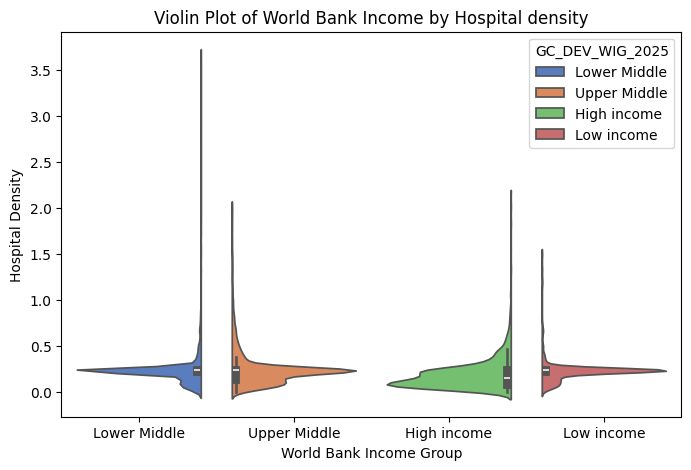

In [11]:
# Violin plot of World Bank Income Group and Hospital amounts
plt.figure(figsize=(8, 5))
sns.violinplot(x='GC_DEV_WIG_2025', y='HL_FDE_HOS_2024', data=EDA_health, split=True, palette='muted', hue='GC_DEV_WIG_2025',legend=True)
plt.title('Violin Plot of World Bank Income by Hospital density')
plt.xlabel('World Bank Income Group')
plt.ylabel('Hospital Density')
plt.show()

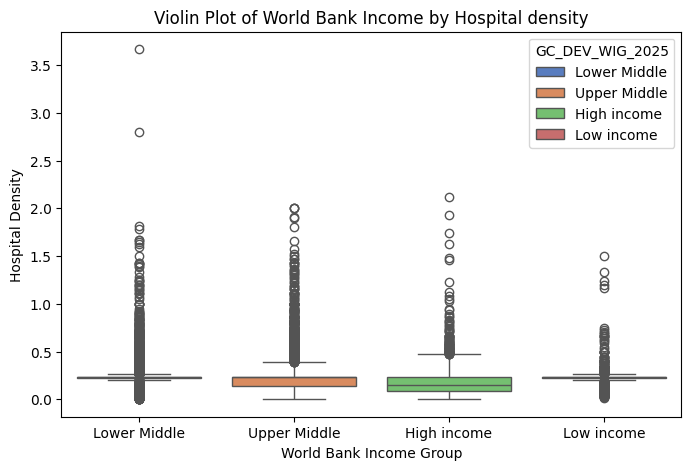

In [12]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='GC_DEV_WIG_2025', y='HL_FDE_HOS_2024', data=EDA_health, palette='muted', hue='GC_DEV_WIG_2025',legend=True)
plt.title('Violin Plot of World Bank Income by Hospital density')
plt.xlabel('World Bank Income Group')
plt.ylabel('Hospital Density')
plt.show()

In [13]:
# Calculates the mean and multiplies by 100 for a clean percentage
regional_data_rates = EDA_health.groupby('GC_DEV_USR_2025')['has_full_pharmacy_data'].mean() * 100

# Sort it so you can instantly see which regions have the most/least data gaps
print(regional_data_rates.sort_values(ascending=False))

GC_DEV_USR_2025
Northern America                    81.407035
Europe                              58.798283
Australia and New Zealand           56.818182
Latin America and the Caribbean     52.066116
Oceania                             16.666667
Eastern and South-Eastern Asia      11.774142
Northern Africa and Western Asia     9.633911
Sub-Saharan Africa                   7.478890
Central and Southern Asia            6.943005
Name: has_full_pharmacy_data, dtype: float64


In [14]:
# Filter the DataFrame to only keep rows where the value is 1
cities_with_data = EDA_health[EDA_health['has_full_pharmacy_data'] == 1]

# Group that newly filtered data and use .size() to get the row count
regional_counts = cities_with_data.groupby('GC_DEV_USR_2025').size()

print(regional_counts.sort_values(ascending=False))

GC_DEV_USR_2025
Europe                              685
Latin America and the Caribbean     567
Eastern and South-Eastern Asia      367
Northern America                    324
Central and Southern Asia           201
Sub-Saharan Africa                  124
Northern Africa and Western Asia    100
Australia and New Zealand            25
Oceania                               3
dtype: int64


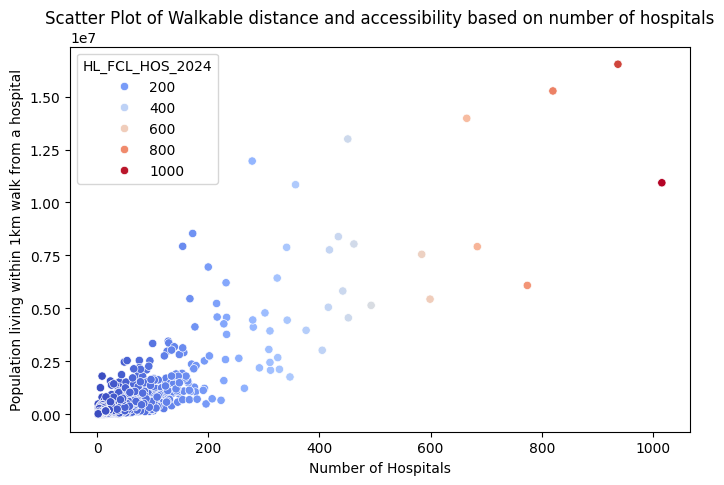

In [15]:
# Walkable distance hospitals
plt.figure(figsize=(8, 5))
sns.scatterplot(x='HL_FCL_HOS_2024', y='HL_POP_HOS_2025', data=EDA_health, hue='HL_FCL_HOS_2024', palette='coolwarm')
plt.title('Scatter Plot of Walkable distance and accessibility based on number of hospitals')
plt.xlabel('Number of Hospitals')
plt.ylabel('Population living within 1km walk from a hospital')
plt.show()

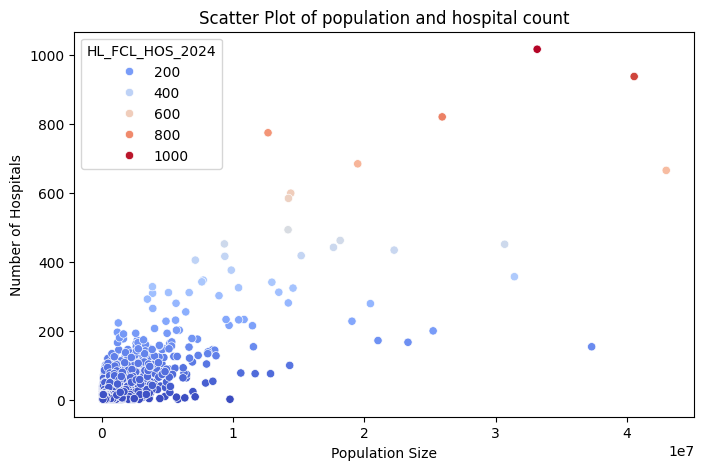

In [16]:
# Visualise if there is a linear connection between population and hospital count
plt.figure(figsize=(8, 5))
sns.scatterplot(x='GC_POP_TOT_2025', y='HL_FCL_HOS_2024', data=EDA_health, hue='HL_FCL_HOS_2024', palette='coolwarm')
plt.title('Scatter Plot of population and hospital count')
plt.xlabel('Population Size')
plt.ylabel('Number of Hospitals')
plt.show()